# SAC — 最大熵与三个核心机制

本 notebook 在 **Pendulum-v1** 上验证 `sac.tex` 中 SAC 的三个核心设计：

1. 自动温度调节（auto α）vs 固定 α；
2. 双 Q 网络（Clipped Double Q）vs 单 Q 网络；
3. 软目标网络更新（τ=0.005）vs 硬拷贝（τ=1.0）。

输出图：
- `fig1_entropy_ablation.pdf`
- `fig2_double_q.pdf`
- `fig3_soft_target_update.pdf`

预计运行时间：约 20–40 分钟（CPU，3 seeds × 10k steps）。

In [ ]:
BREAKRL_CHAPTER = 'sac'

import sys

if 'google.colab' in sys.modules:
    import runpy
    import urllib.request
    from pathlib import Path

    _setup = Path('/content/_breakrl_colab_setup.py')
    _req = urllib.request.Request(
        'https://raw.githubusercontent.com/Powfu-zwx/BreakRL/main/scripts/colab_setup.py' + '?v=2',
        headers={'Cache-Control': 'no-cache'},
    )
    _setup.write_bytes(urllib.request.urlopen(_req).read())
    runpy.run_path(str(_setup))['setup'](BREAKRL_CHAPTER)


In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
import matplotlib
import matplotlib.pyplot as plt

try:
    import gymnasium as gym
    GYM_BACKEND = 'gymnasium'
except ImportError:
    import gym
    GYM_BACKEND = 'gym'

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

BLUE  = '#2166AC'
RED   = '#D6604D'
GRAY  = '#808080'
FIGSIZE = (7.2, 4.8)
OUTDIR  = '.'

ENV_NAME      = 'Pendulum-v1'
N_SEEDS       = 3
MAX_STEPS     = 10000
START_STEPS   = 1000
BATCH_SIZE    = 128
BUFFER_SIZE   = 100000
HIDDEN_DIM    = 128
GAMMA         = 0.99
TAU_DEFAULT   = 0.005
LR            = 3e-4
SMOOTH_WIN    = 10
STEP_GRID     = np.linspace(0, MAX_STEPS, 300)

print(f'Using backend: {GYM_BACKEND}')
print(f'Device: {torch.device("cuda" if torch.cuda.is_available() else "cpu")}')

Using backend: gymnasium
Device: cuda


In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def make_env(name, seed=None):
    env = gym.make(name)
    if seed is not None and hasattr(env.action_space, 'seed'):
        env.action_space.seed(seed)
    return env


def reset_env(env, seed=None):
    out = env.reset(seed=seed) if seed is not None else env.reset()
    return out[0] if isinstance(out, tuple) else out


def step_env(env, action):
    out = env.step(action)
    if len(out) == 5:
        next_state, reward, terminated, truncated, _ = out
        episode_done = terminated or truncated
    else:
        next_state, reward, terminated, episode_done = out
    return next_state, reward, bool(terminated), bool(episode_done)


def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


def smooth(x, w):
    x = np.array(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode='valid')


def plot_mean_std_steps(ax, ep_steps_list, ep_returns_list, color, label, smooth_win=10):
    curves = []
    for ep_steps, ep_returns in zip(ep_steps_list, ep_returns_list):
        s = np.array(ep_steps, dtype=float)
        r = np.array(ep_returns, dtype=float)
        if smooth_win > 1 and len(r) >= smooth_win:
            r = smooth(r, smooth_win)
            s = s[smooth_win - 1:]
        curve = np.interp(STEP_GRID, s, r, left=r[0])
        curves.append(curve)
    arr = np.array(curves)
    mu, std = arr.mean(0), arr.std(0)
    xs = STEP_GRID / 1000.0
    ax.plot(xs, mu, color=color, linewidth=1.5, label=label)
    ax.fill_between(xs, mu - std, mu + std, color=color, alpha=0.15)

In [3]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []
        self.pos = 0

    def push(self, *transition):
        if len(self.buffer) < self.capacity:
            self.buffer.append(transition)
        else:
            self.buffer[self.pos] = transition
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size):
        idx = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in idx]
        s, a, r, ns, terminated = zip(*batch)
        return (
            np.array(s, dtype=np.float32),
            np.array(a, dtype=np.float32),
            np.array(r, dtype=np.float32),
            np.array(ns, dtype=np.float32),
            np.array(terminated, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)

In [4]:
class GaussianActor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mean = nn.Linear(hidden, action_dim)
        self.log_std = nn.Linear(hidden, action_dim)

    def forward(self, state):
        h = self.net(state)
        mean = self.mean(h)
        log_std = self.log_std(h).clamp(-20, 2)
        return mean, log_std

    def sample(self, state, deterministic=False):
        mean, log_std = self(state)
        if deterministic:
            action = torch.tanh(mean)
            return action, None, mean
        std = log_std.exp()
        eps = torch.randn_like(mean)
        u = mean + std * eps
        action = torch.tanh(u)
        log_prob = Normal(mean, std).log_prob(u).sum(-1)
        log_prob -= torch.log(1 - action.pow(2) + 1e-6).sum(-1)
        return action, log_prob, mean


class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, state, action):
        x = torch.cat([state, action], -1)
        return self.net(x).squeeze(-1)

In [5]:
class SACAgent:
    def __init__(self, state_dim, action_dim, hidden=128, lr=3e-4,
                 gamma=0.99, tau=0.005, alpha=0.2,
                 automatic_entropy_tuning=True, use_double_q=True):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.gamma = gamma
        self.tau = tau
        self.action_dim = action_dim
        self.automatic = automatic_entropy_tuning
        self.use_double_q = use_double_q

        self.actor = GaussianActor(state_dim, action_dim, hidden).to(self.device)
        self.actor_opt = torch.optim.Adam(self.actor.parameters(), lr=lr)

        self.q1 = QNetwork(state_dim, action_dim, hidden).to(self.device)
        self.q1_target = QNetwork(state_dim, action_dim, hidden).to(self.device)
        self.q1_target.load_state_dict(self.q1.state_dict())
        self.q1_opt = torch.optim.Adam(self.q1.parameters(), lr=lr)

        if use_double_q:
            self.q2 = QNetwork(state_dim, action_dim, hidden).to(self.device)
            self.q2_target = QNetwork(state_dim, action_dim, hidden).to(self.device)
            self.q2_target.load_state_dict(self.q2.state_dict())
            self.q2_opt = torch.optim.Adam(self.q2.parameters(), lr=lr)

        if automatic_entropy_tuning:
            self.target_entropy = -action_dim
            self.log_alpha = torch.zeros(1, requires_grad=True, device=self.device)
            self.alpha_opt = torch.optim.Adam([self.log_alpha], lr=lr)
            self.alpha = self.log_alpha.exp().item()
        else:
            self.alpha = alpha

    def get_alpha(self):
        if self.automatic:
            return self.log_alpha.exp().item()
        return self.alpha

    def update(self, batch):
        states, actions, rewards, next_states, terminateds = batch
        s = torch.FloatTensor(states).to(self.device)
        a = torch.FloatTensor(actions).to(self.device)
        r = torch.FloatTensor(rewards).to(self.device)
        ns = torch.FloatTensor(next_states).to(self.device)
        terminated = torch.FloatTensor(terminateds).to(self.device)

        alpha = self.get_alpha()

        # Critic target
        with torch.no_grad():
            next_action, next_log_prob, _ = self.actor.sample(ns)
            target_q1 = self.q1_target(ns, next_action)
            if self.use_double_q:
                target_q2 = self.q2_target(ns, next_action)
                target_q = torch.min(target_q1, target_q2)
            else:
                target_q = target_q1
            target_value = r + self.gamma * (1 - terminated) * (target_q - alpha * next_log_prob)

        # Q update
        q1_pred = self.q1(s, a)
        q1_loss = F.mse_loss(q1_pred, target_value)
        self.q1_opt.zero_grad()
        q1_loss.backward()
        self.q1_opt.step()

        if self.use_double_q:
            q2_pred = self.q2(s, a)
            q2_loss = F.mse_loss(q2_pred, target_value)
            self.q2_opt.zero_grad()
            q2_loss.backward()
            self.q2_opt.step()

        # Actor update
        new_action, log_prob, _ = self.actor.sample(s)
        q1_new = self.q1(s, new_action)
        if self.use_double_q:
            q2_new = self.q2(s, new_action)
            min_q_new = torch.min(q1_new, q2_new)
        else:
            min_q_new = q1_new
        actor_loss = (alpha * log_prob - min_q_new).mean()
        self.actor_opt.zero_grad()
        actor_loss.backward()
        self.actor_opt.step()

        # Temperature update
        if self.automatic:
            alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
            self.alpha_opt.zero_grad()
            alpha_loss.backward()
            self.alpha_opt.step()

        # Soft target update
        for p, t in zip(self.q1.parameters(), self.q1_target.parameters()):
            t.data.copy_(self.tau * p.data + (1 - self.tau) * t.data)
        if self.use_double_q:
            for p, t in zip(self.q2.parameters(), self.q2_target.parameters()):
                t.data.copy_(self.tau * p.data + (1 - self.tau) * t.data)

In [6]:
def train_sac(seed, config):
    set_seed(seed)
    env = make_env(ENV_NAME, seed=seed)
    max_action = float(env.action_space.high[0])
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    agent = SACAgent(state_dim, action_dim, **config)
    buffer = ReplayBuffer(BUFFER_SIZE)
    state = reset_env(env, seed=seed)

    ep_returns, ep_steps = [], []
    ep_return = 0.0
    global_step = 0

    while global_step < MAX_STEPS:
        if global_step < START_STEPS:
            raw_action = env.action_space.sample()
            action = raw_action / max_action
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(agent.device)
                action_t, _, _ = agent.actor.sample(state_t, deterministic=False)
                action = action_t.cpu().numpy()[0]

        env_action = action * max_action
        next_state, reward, terminated, episode_done = step_env(env, env_action)
        buffer.push(state, action, reward, next_state, float(terminated))

        state = next_state
        ep_return += reward
        global_step += 1

        if len(buffer) >= BATCH_SIZE and global_step >= START_STEPS:
            agent.update(buffer.sample(BATCH_SIZE))

        if episode_done:
            ep_returns.append(ep_return)
            ep_steps.append(global_step)
            state = reset_env(env)
            ep_return = 0.0

    env.close()
    return ep_returns, ep_steps

In [7]:
def run_experiments(label, config):
    print(f'Running: {label}')
    all_returns, all_steps = [], []
    for seed in range(42, 42 + N_SEEDS):
        ret, st = train_sac(seed, config)
        all_returns.append(ret)
        all_steps.append(st)
        print(f'  seed {seed}: final-10 mean = {np.mean(ret[-10:]):.2f}')
    return all_returns, all_steps

---
## Figure 1 — 自动温度调节 vs 固定 α vs α=0

温度 $\alpha$ 控制「回报 vs 熵」的权衡：$\alpha=0$ 退化为无熵项的纯回报追求，容易过早确定化；固定 $\alpha=0.2$ 依赖手工调参；自动调节把目标熵当作约束、动态调整 $\alpha$，通常更稳（Pendulum-v1，3 个随机种子，阴影为 $\pm 1\sigma$）。

In [8]:
print('=== Experiment 1: entropy temperature ablation ===')

auto_config = {
    'hidden': HIDDEN_DIM, 'lr': LR, 'gamma': GAMMA,
    'tau': TAU_DEFAULT, 'automatic_entropy_tuning': True, 'use_double_q': True,
}

fixed_config = {
    'hidden': HIDDEN_DIM, 'lr': LR, 'gamma': GAMMA,
    'tau': TAU_DEFAULT, 'alpha': 0.2,
    'automatic_entropy_tuning': False, 'use_double_q': True,
}

noent_config = {
    'hidden': HIDDEN_DIM, 'lr': LR, 'gamma': GAMMA,
    'tau': TAU_DEFAULT, 'alpha': 0.0,
    'automatic_entropy_tuning': False, 'use_double_q': True,
}

auto_ret, auto_steps = run_experiments('auto alpha', auto_config)
fixed_ret, fixed_steps = run_experiments('fixed alpha=0.2', fixed_config)
noent_ret, noent_steps = run_experiments('alpha=0', noent_config)

=== Experiment 1: entropy temperature ablation ===
Running: auto alpha


  seed 42: final-10 mean = -204.10


  seed 43: final-10 mean = -135.24


  seed 44: final-10 mean = -415.77
Running: fixed alpha=0.2


  seed 42: final-10 mean = -834.20


  seed 43: final-10 mean = -571.45


  seed 44: final-10 mean = -703.11
Running: alpha=0


  seed 42: final-10 mean = -1151.65


  seed 43: final-10 mean = -461.62


  seed 44: final-10 mean = -989.24


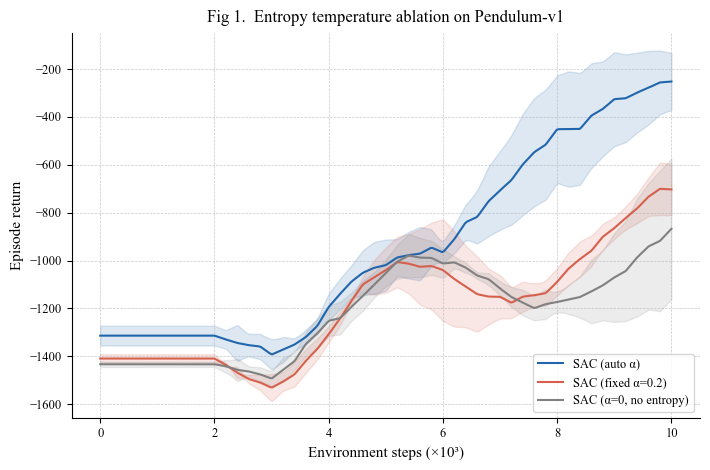

Saved fig1_entropy_ablation.pdf


In [9]:
fig, ax = plt.subplots(figsize=FIGSIZE)

plot_mean_std_steps(ax, auto_steps, auto_ret, BLUE, 'SAC (auto α)', SMOOTH_WIN)
plot_mean_std_steps(ax, fixed_steps, fixed_ret, RED, 'SAC (fixed α=0.2)', SMOOTH_WIN)
plot_mean_std_steps(ax, noent_steps, noent_ret, GRAY, 'SAC (α=0, no entropy)', SMOOTH_WIN)

style_axes(ax)
ax.set_xlabel('Environment steps (×10³)')
ax.set_ylabel('Episode return')
ax.set_title('Fig 1.  Entropy temperature ablation on Pendulum-v1', pad=8)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig1_entropy_ablation.pdf', bbox_inches='tight')
plt.show()
print('Saved fig1_entropy_ablation.pdf')

---
## Figure 2 — 双 Q 网络 vs 单 Q 网络

自举目标取 $\min(Q_1, Q_2)$ 抑制最大化带来的系统性高估：双 Q 版本回报更高、更稳；单 Q 的高估被自举不断放大，拖累策略学习（同上设定）。

In [10]:
print('=== Experiment 2: clipped double Q ===')

double_config = {
    'hidden': HIDDEN_DIM, 'lr': LR, 'gamma': GAMMA,
    'tau': TAU_DEFAULT, 'automatic_entropy_tuning': True, 'use_double_q': True,
}

single_config = {
    'hidden': HIDDEN_DIM, 'lr': LR, 'gamma': GAMMA,
    'tau': TAU_DEFAULT, 'automatic_entropy_tuning': True, 'use_double_q': False,
}

double_ret, double_steps = run_experiments('double Q', double_config)
single_ret, single_steps = run_experiments('single Q', single_config)

=== Experiment 2: clipped double Q ===
Running: double Q


  seed 42: final-10 mean = -203.11


  seed 43: final-10 mean = -148.99


  seed 44: final-10 mean = -194.77
Running: single Q


  seed 42: final-10 mean = -211.19


  seed 43: final-10 mean = -580.12


  seed 44: final-10 mean = -311.69


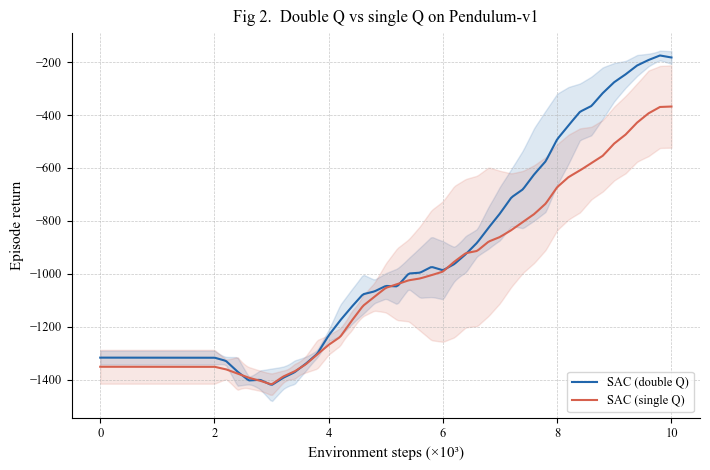

Saved fig2_double_q.pdf


In [11]:
fig, ax = plt.subplots(figsize=FIGSIZE)

plot_mean_std_steps(ax, double_steps, double_ret, BLUE, 'SAC (double Q)', SMOOTH_WIN)
plot_mean_std_steps(ax, single_steps, single_ret, RED, 'SAC (single Q)', SMOOTH_WIN)

style_axes(ax)
ax.set_xlabel('Environment steps (×10³)')
ax.set_ylabel('Episode return')
ax.set_title('Fig 2.  Double Q vs single Q on Pendulum-v1', pad=8)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig2_double_q.pdf', bbox_inches='tight')
plt.show()
print('Saved fig2_double_q.pdf')

---
## Figure 3 — 软目标网络更新 vs 硬拷贝

软更新 $\theta^- \leftarrow \tau\theta + (1-\tau)\theta^-$（$\tau=0.005$）让目标网络缓慢跟随、目标值平滑演化；硬拷贝（$\tau=1.0$）等价于目标随在线网络同步跳变，训练更颠簸（同上设定）。

In [12]:
print('=== Experiment 3: soft target update ===')

soft_config = {
    'hidden': HIDDEN_DIM, 'lr': LR, 'gamma': GAMMA,
    'tau': 0.005, 'automatic_entropy_tuning': True, 'use_double_q': True,
}

hard_config = {
    'hidden': HIDDEN_DIM, 'lr': LR, 'gamma': GAMMA,
    'tau': 1.0, 'automatic_entropy_tuning': True, 'use_double_q': True,
}

soft_ret, soft_steps = run_experiments('tau=0.005', soft_config)
hard_ret, hard_steps = run_experiments('tau=1.0', hard_config)

=== Experiment 3: soft target update ===
Running: tau=0.005


  seed 42: final-10 mean = -215.50


  seed 43: final-10 mean = -150.94


  seed 44: final-10 mean = -734.28
Running: tau=1.0


  seed 42: final-10 mean = -952.74


  seed 43: final-10 mean = -1019.26


  seed 44: final-10 mean = -1064.07


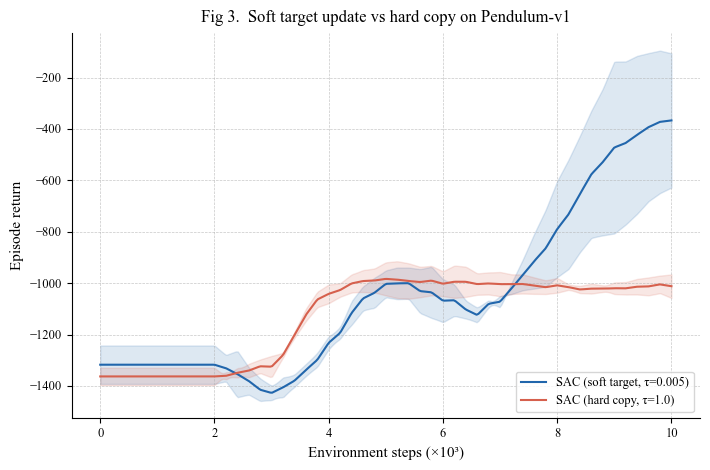

Saved fig3_soft_target_update.pdf


In [13]:
fig, ax = plt.subplots(figsize=FIGSIZE)

plot_mean_std_steps(ax, soft_steps, soft_ret, BLUE, 'SAC (soft target, τ=0.005)', SMOOTH_WIN)
plot_mean_std_steps(ax, hard_steps, hard_ret, RED, 'SAC (hard copy, τ=1.0)', SMOOTH_WIN)

style_axes(ax)
ax.set_xlabel('Environment steps (×10³)')
ax.set_ylabel('Episode return')
ax.set_title('Fig 3.  Soft target update vs hard copy on Pendulum-v1', pad=8)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig3_soft_target_update.pdf', bbox_inches='tight')
plt.show()
print('Saved fig3_soft_target_update.pdf')

In [14]:
print('All figures saved:')
print('  fig1_entropy_ablation.pdf')
print('  fig2_double_q.pdf')
print('  fig3_soft_target_update.pdf')

All figures saved:
  fig1_entropy_ablation.pdf
  fig2_double_q.pdf
  fig3_soft_target_update.pdf


## 小结

- **最大熵目标**让策略在优化回报的同时保持随机性，自动温度调节免去手调 $\alpha$；
- **双 Q 取 min** 对付高估偏差，**软目标更新**对付目标漂移——两者都是稳定自举的手段；
- 三个机制各自可拆解验证，组合起来才是 SAC 在连续控制上稳定高效的原因。